In [1]:
import duckdb
import os
import pandas
import matplotlib.pyplot as plt
import polars as pl
import pandas as pd
from lifelines import KaplanMeierFitter
from lifelines import WeibullFitter
from lifelines import WeibullAFTFitter
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
os.chdir("..")

In [3]:
con = duckdb.connect("uk_car_analyser.duckdb")

In [4]:
con.execute("""
    COPY(
        WITH last_test_prep AS(
           SELECT vehicle_id, (DATE_DIFF('day', first_use_date, test_date))/365.25 AS t, 
           IF(test_result IN ('ABA', 'F'), 1, 0) AS event,
           IF(
               test_result NOT IN ('ABA', 'F') AND test_date<'2024-12-31',
               1,
               0
            ) AS interval_censored,
           make, model, 
           fuel_type, cylinder_capacity, test_mileage,
           first_use_date AS start_date, test_date AS end_date,
           ROW_NUMBER()OVER(PARTITION BY vehicle_id ORDER BY test_date DESC, test_id DESC) AS rownum
           
           FROM read_parquet('data/mot_data_combined.parquet')
           WHERE first_use_date<test_date
           
        )
    
        SELECT * EXCLUDE(rownum) FROM last_test_prep WHERE rownum=1
    ) TO 'data/mot_last_test.parquet' (FORMAT PARQUET); 
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [25]:
df = pl.scan_parquet('data/mot_last_test.parquet').collect()

In [26]:
# df = df.filter(pl.col('start_date')>=pl.lit('1900-01-01').str.to_date())
# df = df.filter(pl.col('event')==1)

df = df.to_pandas()

In [72]:
# test for interval censoring
df['test_mileage'] = df['test_mileage'].replace(0,1)
df['test_mileage_upper'] = df['test_mileage'].copy()
df.loc[df['event'] == 0, 'test_mileage_upper'] = df.loc[df['event'] == 0, 'test_mileage'] + 7000

In [73]:
df['end_date'] = pd.to_datetime(df['end_date'])

In [5]:
print(df['mileage'].mean())

96155.29920588137


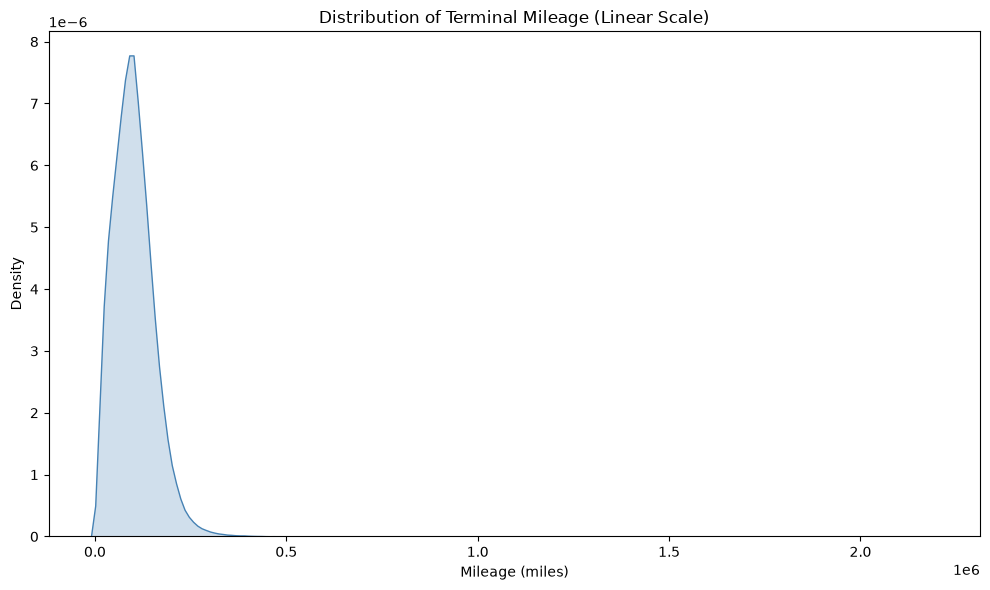

In [25]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="interval_mileage", fill=True, color="steelblue")
plt.title("Distribution of Terminal Mileage (Linear Scale)")
plt.xlabel("Mileage (miles)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

In [11]:
kmf = KaplanMeierFitter()

kmf.fit(
    df['mileage'],
    event_observed=df['event']
)

D:\DataScience\Portfolio\UK Car Analyser\.venv\Lib\site-packages\lifelines\utils\__init__.py:1185: UserWarning: Attempting to convert an unexpected datatype 'object' to float. Suggestion: 1) use `lifelines.utils.datetimes_to_durations` to do conversions or 2) manually convert to floats/booleans.
  warnings.warn(warning_text, UserWarning)


<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 1.10487e+06 total observations, 1.04385e+06 right-censored observations>

<Axes: xlabel='timeline'>

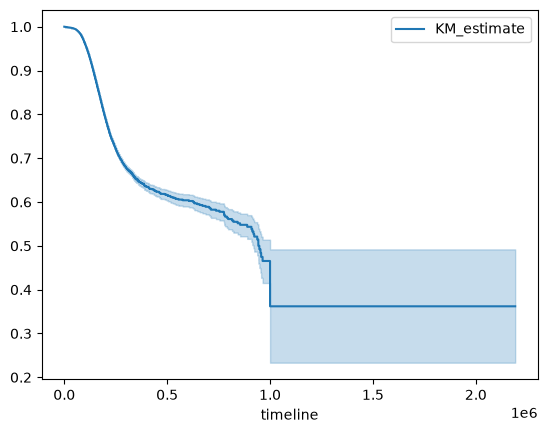

In [12]:
kmf.plot()

In [ ]:
kmf.plot()

In [13]:
print(f"Median Survival Mileage: {kmf.median_survival_time_:.0f} miles")

Median Survival Mileage: 943168 miles


In [33]:
kmf = KaplanMeierFitter()

kmf.fit(
    df['mileage_interval'],
    event_observed=df['event_interval']
)

D:\DataScience\Portfolio\UK Car Analyser\.venv\Lib\site-packages\lifelines\utils\__init__.py:1185: UserWarning: Attempting to convert an unexpected datatype 'object' to float. Suggestion: 1) use `lifelines.utils.datetimes_to_durations` to do conversions or 2) manually convert to floats/booleans.
  warnings.warn(warning_text, UserWarning)


<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 1.10356e+06 total observations, 0 right-censored observations>

<Axes: xlabel='timeline'>

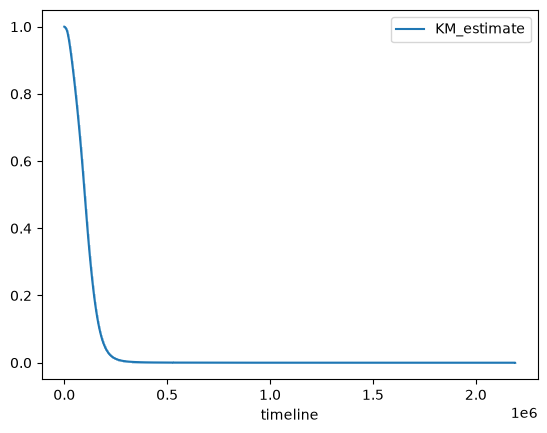

In [34]:
kmf.plot()

In [35]:
print(f"Median Survival Mileage: {kmf.median_survival_time_:.0f} miles")

Median Survival Mileage: 99386 miles


In [27]:
counts = df['make'].value_counts()

# 2. Identify makes with > 5000 entries
valid_makes = counts[counts > 100].index

# 3. Filter the dataframe
df_sample = df[df['make'].isin(valid_makes)]
df_sample = df_sample.sample(frac=0.3, random_state=123)

In [28]:
weibull_aft = WeibullAFTFitter()

weibull_aft.fit(
    df_sample,
    duration_col = 'mileage_interval',
    event_col = 'event_interval',
    formula = 'engineSize'
)

<lifelines.WeibullAFTFitter: fitted with 330103 total observations, 0 right-censored observations>

In [29]:
lambda_coeffs = weibull_aft.summary.loc['lambda_']['coef']

In [31]:
sorted_coeffs = lambda_coeffs.sort_values(ascending=False)

In [32]:
sorted_coeffs.head(5)

covariate
Intercept     11.085142
engineSize     0.000327
Name: coef, dtype: float64

In [23]:
sorted_coeffs.tail(5)

covariate
make[T.MORGAN]            -0.663961
make[T.KTM]               -0.677665
make[T.HARLEY-DAVIDSON]   -0.729891
make[T.APRILIA]           -0.733884
make[T.DUCATI]            -1.113666
Name: coef, dtype: float64

In [15]:
con.execute("""
SELECT min(first_use_date) FROM read_parquet('data/mot_data_combined.parquet')
           WHERE first_use_date<'1960-01-01'

""").df()

,min(first_use_date)
0,1-01-01


In [57]:
del df_sample